In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [36]:
df = pd.read_csv("s2.csv")

In [37]:
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2016,5,3.07,6.83,1623.69
1,2013,7,5.49,5.00,1620.59
2,2022,7,6.15,6.57,1451.84
3,2024,11,7.92,11.03,1261.76
4,2020,4,1.39,4.32,1762.35


In [38]:
df.drop(columns = ["year" , "month"] , axis = 1 , inplace = True)


In [39]:
df.head()   

,interest_rate,unemployment_rate,index_price
0,3.07,6.83,1623.69
1,5.49,5.00,1620.59
2,6.15,6.57,1451.84
3,7.92,11.03,1261.76
4,1.39,4.32,1762.35


In [40]:
# check null values
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

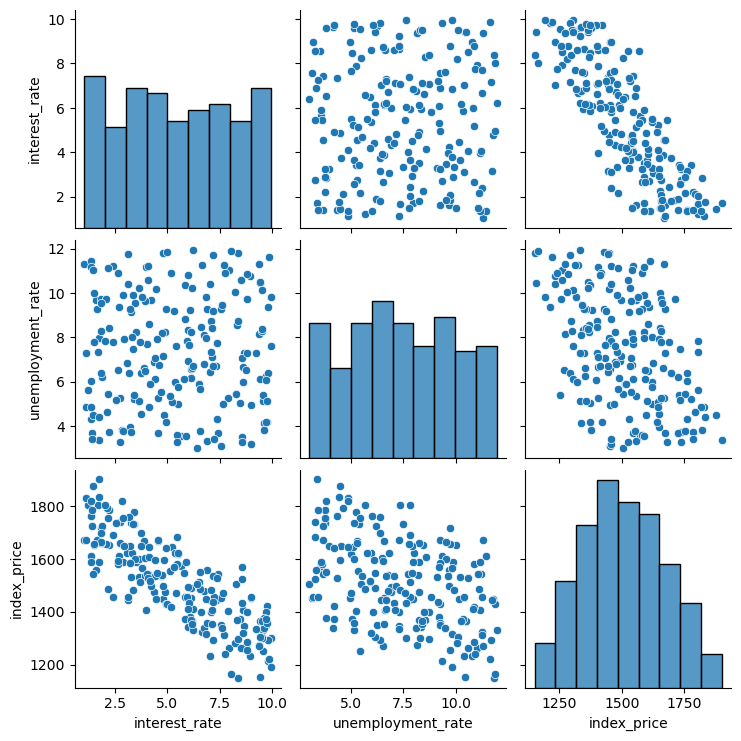

In [41]:
sns.pairplot(df)

In [42]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,0.012402,-0.829406
unemployment_rate,0.012402,1.000000,-0.461066
index_price,-0.829406,-0.461066,1.000000


In [43]:
X = df.iloc[:,:-1]
y = df.iloc[: , -1]

In [44]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

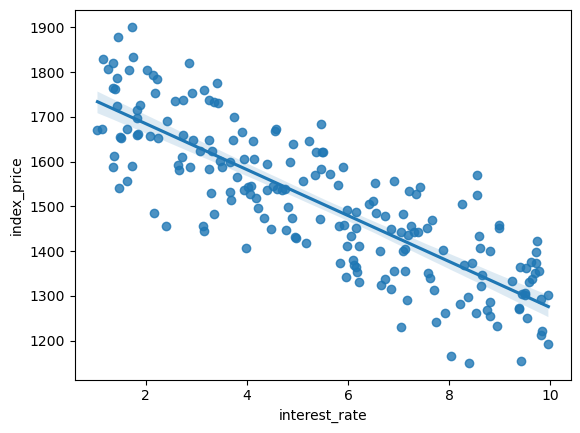

In [45]:
sns.regplot(x=df["interest_rate"], y=df["index_price"])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

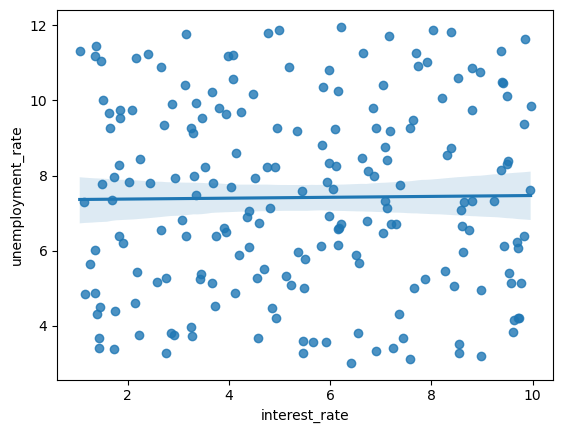

In [46]:
sns.regplot(x=df["interest_rate"], y=df["unemployment_rate"])

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
regression = LinearRegression()
regression.fit(X_train_scaled,y_train)

LinearRegression()

In [49]:
score = cross_val_score(regression, X_train_scaled,y_train,cv = 3,scoring="neg_mean_squared_error")
np.mean(score)

-2863.7105882870783

In [53]:
y_pred = regression.predict(X_test_scaled)
y_pred

array([1419.44672347, 1699.90584913, 1610.15735861, 1561.83112924,
       1328.07522444, 1214.06951359, 1637.93852271, 1584.48621223,
       1390.65472209, 1797.39202309, 1768.96006082, 1591.60194253,
       1533.03071823, 1542.40075634, 1240.76881727, 1426.66057883,
       1723.30406036, 1469.80571665, 1627.10752196, 1435.2000171 ,
       1287.01213085, 1623.82374953, 1344.83268882, 1530.41282015,
       1358.92303967, 1611.47982613, 1395.29205091, 1602.54838834,
       1383.47949367, 1418.22013718, 1285.13075946, 1675.78444429,
       1366.94973909, 1510.02668538, 1517.40968894, 1802.42353029,
       1618.75984615, 1599.51637723, 1468.38867522, 1276.00444383,
       1678.52395324, 1254.41078587, 1499.97831138, 1631.58056106,
       1340.50082444, 1388.85901422, 1666.69008907, 1554.98659417,
       1480.53286231, 1618.52945675])

In [54]:
regression.coef_

array([-134.22711408,  -77.36178816])

In [59]:
# performance metrics
mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test , y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared Score:", r2)

Mean Squared Error: 3549.0371572418658
Mean Absolute Error: 49.948511541129776
Root Mean Squared Error: 59.57379589418376
R-squared Score: 0.8631351051922934


In [61]:
# adjusted r2_score
adjust = 1 - (1-r2)* len(y_test)-1/(len(y_test)-X_test_scaled.shape[1]-1)
adjust

-5.86452133613001

Text(0.5, 0, 'Actual Values')

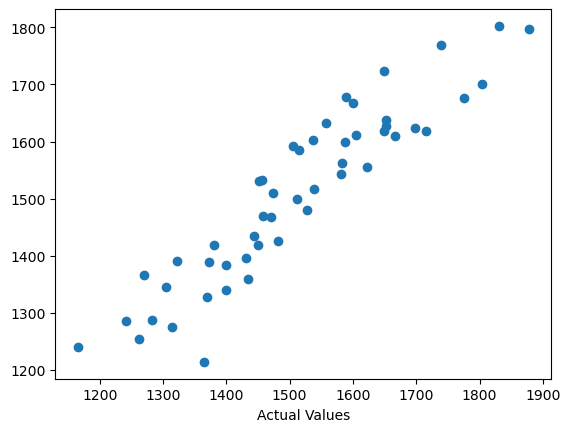

In [62]:
# assumptions 
plt.scatter(y_test , y_pred)
plt.xlabel("Actual Values") 

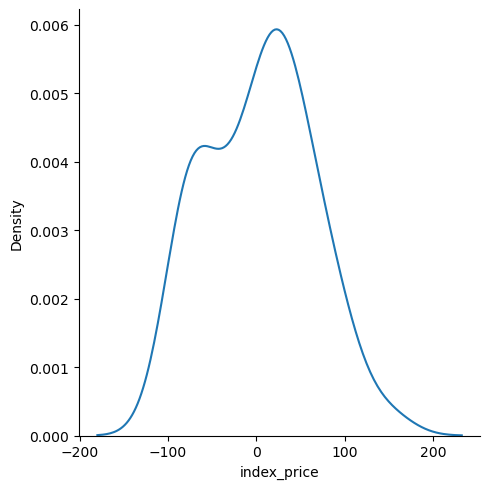

In [64]:
residuals = y_test - y_pred
sns.displot(residuals, kind = "kde")

OLS PRED


In [69]:
import statsmodels.api as sm
model = sm.OLS(y_train , X_train).fit()
prediction = model.predict(X_test)
print(prediction)


95     1654.621210
15     1115.698767
30     1154.384587
158    1480.444719
128    1702.300896
115    2035.936291
69     1301.659645
170    1306.867417
174    1366.364512
45      711.217901
66      626.430417
182     821.488214
165    1628.885132
78     1665.902857
186    2141.791601
177    1456.596278
56      750.203429
152    1453.343100
82     1471.384353
68     1383.243483
124    1902.889745
16     1117.390205
148    1439.614025
93      907.997084
65     1516.483154
60     1141.787845
84     1947.453013
67     1056.474277
125    1651.877376
132    1532.809396
9      1990.790574
18      936.986797
55     1453.719215
75     1441.811962
150    1431.579408
104     739.737896
135    1275.920036
137    1624.280078
164    1173.607476
76     2037.025238
79     1204.125679
197    1997.396908
38     1222.612621
24     1432.961460
122    1563.407079
195    1192.544095
29      938.418610
19     1160.747807
143    1712.477085
86     1457.249215
dtype: float64


In [70]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.867
Model:                            OLS   Adj. R-squared (uncentered):              0.865
Method:                 Least Squares   F-statistic:                              483.2
Date:                Mon, 02 Mar 2026   Prob (F-statistic):                    1.32e-65
Time:                        16:34:23   Log-Likelihood:                         -1160.0
No. Observations:                 150   AIC:                                      2324.
Df Residuals:                     148   BIC:                                      2330.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------